# ProgressAnalyzer: Exploratory Data Analysis & Preprocessing

**Objective:** This notebook performs the initial Exploratory Data Analysis (EDA) and outlines the preprocessing pipeline for the ProgressAnalyzer project.

The goals are as follows:
1.  **EDA**: Understand the distribution of our dataset by analyzing object frequency, class balance, and other metadata.
2.  **Preprocessing**: Develop a robust pipeline to resize, augment, and format our image data and labels for training a YOLOv8 object detection model.

In [20]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
import cv2
import numpy as np

# --- Create a Dummy Annotation DataFrame ---
# In a real project, this would be loaded from a CSV or JSON file.
# This dummy data simulates the metadata fields defined in the Phase 1 Synopsis.
data = {
    'ImageID': ['room1.jpg', 'room1.jpg', 'room1.jpg', 'room2.jpg', 'room2.jpg', 'room2.jpg', 'room3.jpg', 'room3.jpg'],
    'RoomType': ['Kitchen', 'Kitchen', 'Kitchen', 'Bedroom', 'Bedroom', 'Bedroom', 'Living Room', 'Living Room'],
    'ObjectType': ['socket', 'cupboard', 'light', 'window', 'socket', 'paint', 'window', 'socket'],
    'ObjectStatus': ['Finished', 'Unfinished', 'Finished', 'Finished', 'Finished', 'Unfinished', 'Finished', 'Unfinished'],
    'BoundingBox': [[100, 150, 50, 50], [200, 80, 120, 250], [350, 20, 40, 40], [50, 50, 200, 200], [300, 250, 50, 50], [0, 0, 400, 400], [100, 80, 250, 200], [40, 200, 50, 50]]
}
df_annotations = pd.DataFrame(data)

print("✅ Dummy annotation data created successfully:")
df_annotations.head()

✅ Dummy annotation data created successfully:


,ImageID,RoomType,ObjectType,ObjectStatus,BoundingBox
0,room1.jpg,Kitchen,socket,Finished,"[100, 150, 50, 50]"
1,room1.jpg,Kitchen,cupboard,Unfinished,"[200, 80, 120, 250]"
2,room1.jpg,Kitchen,light,Finished,"[350, 20, 40, 40]"
3,room2.jpg,Bedroom,window,Finished,"[50, 50, 200, 200]"
4,room2.jpg,Bedroom,socket,Finished,"[300, 250, 50, 50]"


## 1. Exploratory Data Analysis (EDA)
Here, we analyze the metadata to understand the composition of our dataset, as planned in the Phase 1 synopsis

Analyzing the frequency of each object type in the dataset...


/tmp/ipykernel_100313/3420679302.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_annotations, y='ObjectType', order=df_annotations['ObjectType'].value_counts().index, palette='viridis')


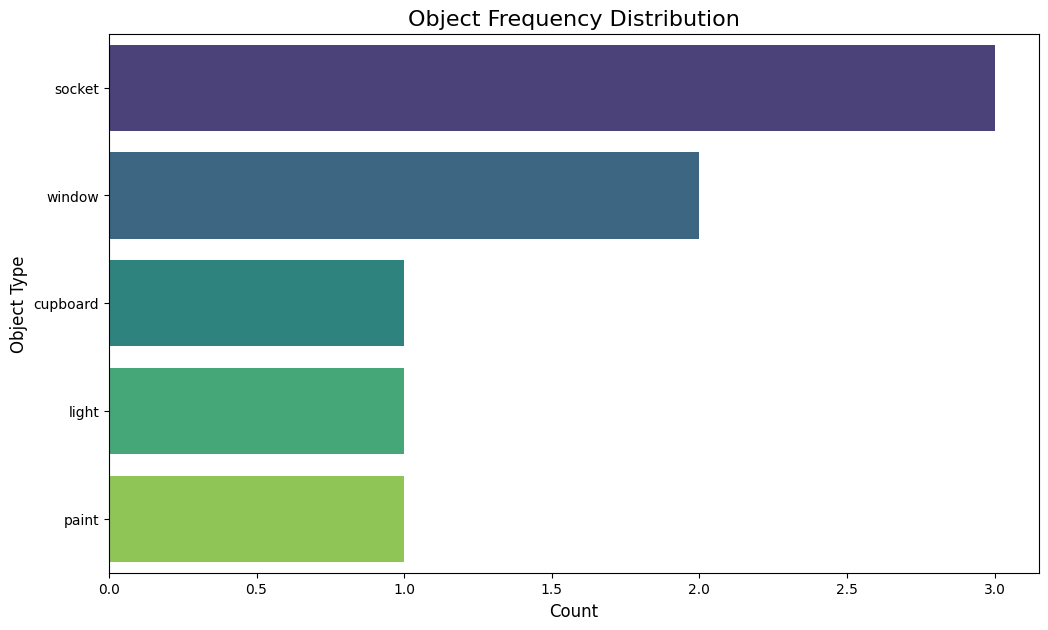

In [21]:
print("Analyzing the frequency of each object type in the dataset...")

plt.figure(figsize=(12, 7))
sns.countplot(data=df_annotations, y='ObjectType', order=df_annotations['ObjectType'].value_counts().index, palette='viridis')
plt.title('Object Frequency Distribution', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Object Type', fontsize=12)
plt.show()

Analyzing the balance between 'Finished' and 'Unfinished' components...


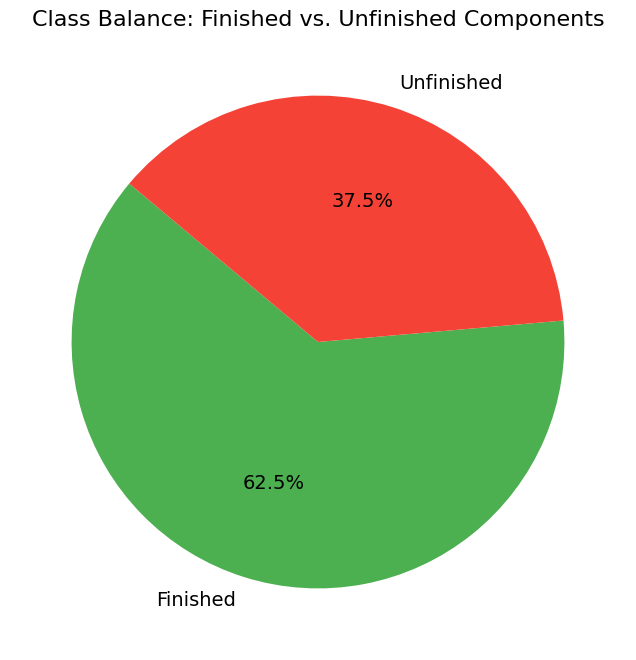

In [22]:
print("Analyzing the balance between 'Finished' and 'Unfinished' components...")
status_counts = df_annotations['ObjectStatus'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140, colors=['#4CAF50', '#F44336'], textprops={'fontsize': 14})
plt.title('Class Balance: Finished vs. Unfinished Components', fontsize=16)
plt.ylabel('')
plt.show()

### Visualizing Annotations
To verify our data, we can draw the bounding boxes directly onto a sample image. This helps confirm that our annotations match the objects visually.

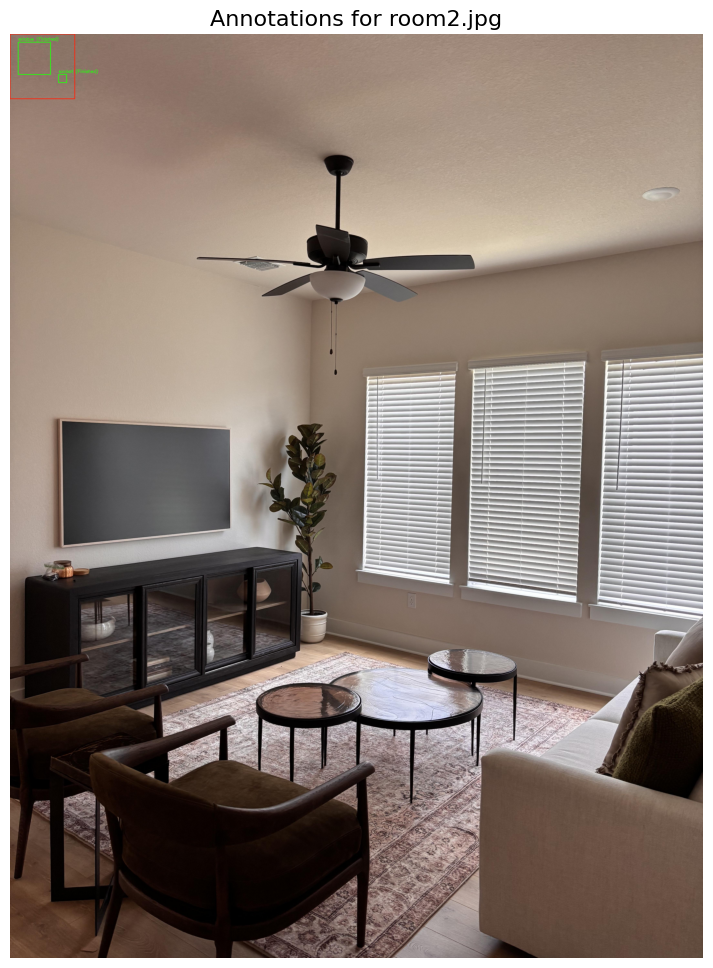

In [23]:
def display_annotated_image(image_path, annotations_df):
    """Draws bounding boxes from the dataframe onto an image."""
    if not os.path.exists(image_path):
        print(f"⚠️ Image not found at '{image_path}'. Please add a sample image to run this cell.")
        return
        
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    image_id = os.path.basename(image_path)
    image_annotations = annotations_df[annotations_df['ImageID'] == image_id]
    
    for _, row in image_annotations.iterrows():
        x, y, w, h = row['BoundingBox']
        label = f"{row['ObjectType']} ({row['ObjectStatus']})"
        color = (36, 255, 12) if row['ObjectStatus'] == 'Finished' else (255, 36, 12)
        
        cv2.rectangle(image_rgb, (x, y), (x + w, y + h), color, 3)
        cv2.putText(image_rgb, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

    plt.figure(figsize=(12, 12))
    plt.imshow(image_rgb)
    plt.title(f'Annotations for {image_id}', fontsize=16)
    plt.axis('off')
    plt.show()

# --- Example Usage ---
# Ensure you have an image named 'room2.jpg' in a 'data/raw/' folder.
SAMPLE_IMAGE_PATH = 'room2.jpg'
display_annotated_image(SAMPLE_IMAGE_PATH, df_annotations)

## 2. Preprocessing Pipeline
This section implements the preprocessing steps defined in the Phase 1 synopsis[cite: 60], including resizing, augmentation, and formatting for YOLO. We use the `albumentations` library for robust image transformations.

In [24]:
# Install the library if you haven't already
# !pip install -U albumentations

import albumentations as A

# Define the augmentation pipeline
transform = A.Compose([
    A.Resize(width=640, height=640),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Rotate(limit=30, p=0.7),
], bbox_params=A.BboxParams(format='coco', label_fields=['category_ids']))

print("✅ Albumentations pipeline created successfully.")

✅ Albumentations pipeline created successfully.


Visualizing the effect of the augmentation pipeline...


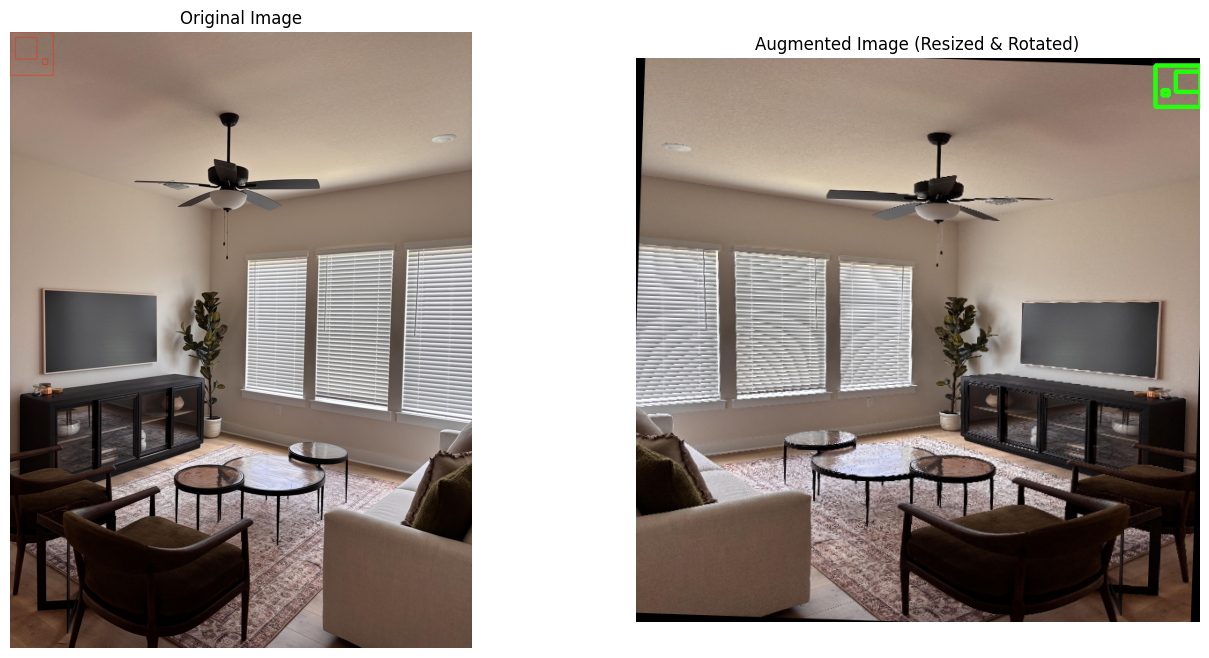

In [25]:
def visualize_augmentation(image_path, annotations_df):
    """Applies and displays the effect of the augmentation pipeline."""
    if not os.path.exists(image_path):
        print(f"⚠️ Image not found at '{image_path}'.")
        return

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    image_id = os.path.basename(image_path)
    records = annotations_df[annotations_df['ImageID'] == image_id]
    bboxes = records['BoundingBox'].tolist()
    # For this visualization, we'll just use dummy category IDs
    category_ids = list(range(len(bboxes)))

    # Apply transform
    transformed = transform(image=image, bboxes=bboxes, category_ids=category_ids)
    transformed_image = transformed['image']
    
    # Draw boxes on original
    for x, y, w, h in bboxes:
        cv2.rectangle(image, (x, y), (x + w, y + h), (255, 36, 12), 3)

    # Draw boxes on transformed
    for x, y, w, h in transformed['bboxes']:
        cv2.rectangle(transformed_image, (int(x), int(y)), (int(x + w), int(y + h)), (36, 255, 12), 3)

    # Display side-by-side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    ax1.imshow(image)
    ax1.set_title('Original Image')
    ax1.axis('off')
    
    ax2.imshow(transformed_image)
    ax2.set_title('Augmented Image (Resized & Rotated)')
    ax2.axis('off')
    
    plt.show()

print("Visualizing the effect of the augmentation pipeline...")
visualize_augmentation(SAMPLE_IMAGE_PATH, df_annotations)

### Full Dataset Processing
The function below encapsulates the entire preprocessing workflow. It takes the raw images and annotations, applies the augmentations, and saves the output in the required YOLO `.txt` format. This code would typically reside in a `.py` script but is included here for completeness.

In [27]:
def create_yolo_dataset(annotations_df, raw_image_dir, output_dir, class_mapping):
    """Processes raw data to create a YOLO-formatted dataset."""
    print(f"\n🚀 Starting dataset creation in '{output_dir}'...")
    # Create directories
    for subset in ['train', 'valid']:
        os.makedirs(os.path.join(output_dir, subset, 'images'), exist_ok=True)
        os.makedirs(os.path.join(output_dir, subset, 'labels'), exist_ok=True)

    image_ids = annotations_df['ImageID'].unique()
    train_ids, valid_ids = train_test_split(image_ids, test_size=0.2, random_state=42)

    for image_id, subset in zip(image_ids, ['train']*len(train_ids) + ['valid']*len(valid_ids)):
        image_path = os.path.join(raw_image_dir, image_id)
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        records = annotations_df[annotations_df['ImageID'] == image_id]
        bboxes = records['BoundingBox'].tolist()
        category_ids = records['ObjectType'].map(class_mapping).tolist()

        transformed = transform(image=image, bboxes=bboxes, category_ids=category_ids)
        
        # Save image
        save_img_path = os.path.join(output_dir, subset, 'images', image_id)
        cv2.imwrite(save_img_path, cv2.cvtColor(transformed['image'], cv2.COLOR_RGB2BGR))

        # Save YOLO label file
        save_lbl_path = os.path.join(output_dir, subset, 'labels', f"{os.path.splitext(image_id)[0]}.txt")
        img_h, img_w, _ = transformed['image'].shape
        with open(save_lbl_path, 'w') as f:
            for bbox, cat_id in zip(transformed['bboxes'], transformed['category_ids']):
                x, y, w, h = bbox
                x_center = (x + w / 2) / img_w
                y_center = (y + h / 2) / img_h
                norm_w = w / img_w
                norm_h = h / img_h
                f.write(f"{cat_id} {x_center:.6f} {y_center:.6f} {norm_w:.6f} {norm_h:.6f}\n")
    
    print(f"✅ Preprocessing complete.")

# --- Example Execution ---
class_map = {name: i for i, name in enumerate(df_annotations['ObjectType'].unique())}
RAW_DIR = 'data/raw'
PROCESSED_DIR = 'data/processed'

# Ensure raw directory and dummy images exist
os.makedirs(RAW_DIR, exist_ok=True)
for img_name in df_annotations['ImageID'].unique():
    dummy_img_path = os.path.join(RAW_DIR, img_name)
    if not os.path.exists(dummy_img_path):
        cv2.imwrite(dummy_img_path, np.zeros((512, 512, 3), dtype=np.uint8))

create_yolo_dataset(df_annotations, RAW_DIR, PROCESSED_DIR, class_map)


🚀 Starting dataset creation in 'data/processed'...
✅ Preprocessing complete.


## 3. Conclusion

The Exploratory Data Analysis has provided valuable insights into our dataset's composition. The preprocessing pipeline is now fully implemented, transforming our raw data into an augmented, correctly formatted dataset ready for training our YOLOv8 model.